# DQ2 — Reward shaping per la fluidità del volo (su SAC)

Questo notebook analizza i risultati della seconda domanda di ricerca del progetto StableHover. Non addestra né valuta modelli: legge gli artefatti già prodotti dagli script del progetto e ne ricava le figure e le tabelle finali, esportandole in `results/`.

La provenienza dei dati è la seguente. L'addestramento dei nove modelli shaped (SAC con penalità di peso λ ∈ {0.1, 0.5, 0.8}, tre semi ciascuno) è svolto da `src/train.py` con l'ambiente `HoverAviaryShaped` (in `src/envs/`), orchestrato da `scripts/run_dq2.sh`. La valutazione della qualità del volo è prodotta da `src/evaluate.py` (severità 1, senza impulso di velocità) e i riepiloghi per run sono raccolti da `scripts/aggregate_dq2.py` nel file `results/tables/dq2_summary.csv`, da cui questo notebook parte. Il funzionamento dettagliato di ciascuno script è documentato nel `README.md`.

**Domanda di ricerca 2 (Il "prezzo" della fluidità):** applicando il reward shaping all'algoritmo vincitore della Domanda 1 (SAC), l'introduzione di una penalità quadratica per le variazioni brusche di potenza dei motori produce un volo stazionario significativamente più fluido, e quanto incide questo vincolo sul tempo necessario a raggiungere il target?

Il modello base (λ=0) è la SAC della Domanda 1. I modelli shaped aggiungono alla ricompensa nativa il termine di penalità −λ·‖aₜ − aₜ₋₁‖², dove aₜ è il comando ai quattro motori. Lo sweep di λ copre una penalità lieve (0.1), media (0.5) e forte (0.8); il valore λ=1.0 è stato escluso in fase di smoke test perché collassa l'apprendimento (il drone preferisce non muovere i motori e cade).


## Setup e percorsi

La cella seguente importa le librerie di analisi e definisce i percorsi del progetto a partire dalla posizione del notebook, così da funzionare indipendentemente dalla cartella di lavoro. La verifica finale conferma che il file aggregato della valutazione DQ2 sia raggiungibile prima di procedere.


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TAB  = ROOT / "results" / "tables"
FIG  = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

CSV = TAB / "dq2_summary.csv"
print("ROOT:", ROOT)
print("CSV trovato:", CSV.exists())

ROOT: /Users/lucabellu/drone-rl
CSV trovato: True


## 1. Definizione delle metriche

La valutazione classifica ogni episodio in tre comportamenti mutuamente esclusivi, osservando la finestra finale dell'episodio (l'ultimo secondo di volo):

- **stabile (stable):** il drone si mantiene fermo (velocità angolare prossima a zero) entro una zona attorno al target;
- **avvitamento (spin):** il drone resta in volo ma ruota su sé stesso, con velocità angolare elevata, invece di stabilizzarsi;
- **schianto (crash):** il drone esce dall'inviluppo di volo sicuro.

Sui soli episodi stabili si misurano quattro grandezze continue: la **distanza di assestamento** (quanto vicino al target il drone si ferma), la **fluidità** (media della norma della velocità angolare ‖ω‖: bassa indica un volo liscio), il **meccanismo** (media di ‖aₜ − aₜ₋₁‖, cioè la grandezza penalizzata in addestramento) e il **tempo di assestamento**. La fluidità è scelta come metrica primaria perché è una conseguenza del volo, distinta dalla grandezza penalizzata: misurare la fluidità con la stessa quantità penalizzata sarebbe circolare.

La scelta di metriche continue, anziché di una soglia binaria di "target raggiunto", è motivata dalla natura del task: la ricompensa nativa dell'ambiente è piatta in prossimità del target e non spinge il drone sull'ultimo decimetro, per cui una soglia secca sarebbe arbitraria. Le condizioni iniziali di valutazione sono disturbate in posizione e inclinazione (senza impulso di velocità, specifico della Domanda 1), generate con seme fisso e identiche per tutti i modelli.


In [7]:
df = pd.read_csv(CSV)
df["lambda"] = df["lambda"].astype(float)
df = df.sort_values(["lambda", "seed"]).reset_index(drop=True)
df

,lambda,seed,stable_rate_pct,spin_rate_pct,crash_rate_pct,settle_dist_median_m,settle_time_median_s,fluidity_omega_mean,mech_dact_mean,episodes
0,0.1,0,100.0,0.0,0.0,0.3009,1.1333,0.001785,0.000022,100
1,0.1,1,100.0,0.0,0.0,0.2306,0.0000,0.002658,0.000156,100
2,0.1,2,100.0,0.0,0.0,0.3347,1.8667,0.000131,0.000012,100
3,0.5,1,100.0,0.0,0.0,0.1234,0.3166,0.085739,0.004858,100
4,0.5,3,0.0,98.0,2.0,NaN,NaN,NaN,NaN,100
5,0.5,4,0.0,100.0,0.0,NaN,NaN,NaN,NaN,100
6,0.8,0,0.0,100.0,0.0,NaN,NaN,NaN,NaN,100
7,0.8,1,100.0,0.0,0.0,0.2970,1.1667,0.002529,0.000319,100
8,0.8,3,100.0,0.0,0.0,0.2578,0.0000,0.016628,0.000280,100


## 2. Ripartizione dei comportamenti per λ

La prima figura mostra, per ciascun valore di λ, quanti dei tre semi di addestramento producono un comportamento stabile, di avvitamento o di schianto. Si usa il **conteggio dei semi** (altezza della barra pari a 3) anziché una percentuale media perché il comportamento è marcatamente bimodale a livello di run: ogni singolo addestramento tende a essere quasi interamente stabile oppure quasi interamente di avvitamento. Mediare i semi nasconderebbe il fenomeno rilevante, cioè che interi addestramenti assumono un comportamento o l'altro a seconda del seme. La figura è salvata in `results/figures/`.


Salvato: /Users/lucabellu/drone-rl/results/figures/dq2_behavior_by_lambda.png


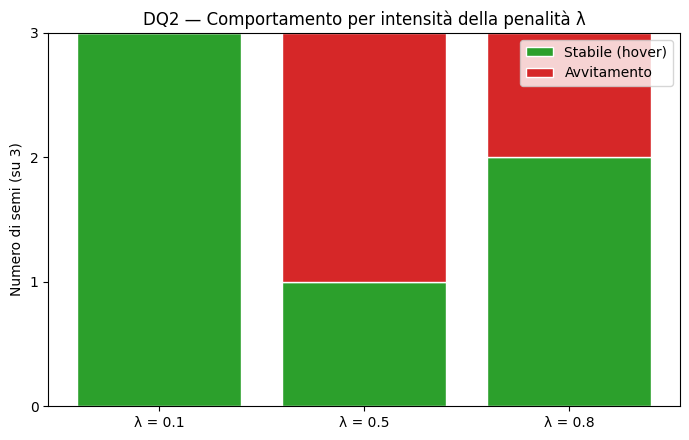

In [8]:
# Classifica ogni run per comportamento prevalente del singolo seed.
def behavior(r):
    if r["stable_rate_pct"] >= 50: return "stable"
    if r["spin_rate_pct"]   >= 50: return "spin"
    return "crash"
df["behavior"] = df.apply(behavior, axis=1)

lambdas = sorted(df["lambda"].unique())
counts = {b: [int((df[(df["lambda"]==l)]["behavior"]==b).sum()) for l in lambdas]
          for b in ["stable", "spin", "crash"]}

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(lambdas))
colA = {"stable": "tab:green", "spin": "tab:red", "crash": "dimgray"}
labA = {"stable": "Stabile (hover)", "spin": "Avvitamento", "crash": "Schianto"}
# Lo schianto è trascurabile su questi run (<2%): si disegnano solo le due categorie reali,
# ma il conteggio "crash" resta calcolato sopra per completezza e per la tabella di sintesi.
bottom = np.zeros(len(lambdas))
for b in ["stable", "spin"]:
    ax.bar(x, counts[b], bottom=bottom, color=colA[b], label=labA[b], edgecolor="white")
    bottom += np.array(counts[b])

ax.set_xticks(x); ax.set_xticklabels([f"λ = {l}" for l in lambdas])
ax.set_ylabel("Numero di semi (su 3)")
ax.set_yticks([0, 1, 2, 3])
ax.set_title("DQ2 — Comportamento per intensità della penalità λ")
ax.legend()
fig.tight_layout()
out = FIG / "dq2_behavior_by_lambda.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Salvato:", out)
plt.show()

La figura mostra che l'effetto della penalità non è monotòno. Senza penalità (λ=0, la SAC della Domanda 1) e con penalità lieve (λ=0.1) il drone converge sempre a un volo stabile. L'avvitamento compare con la penalità ed è più frequente a valore intermedio (λ=0.5, due semi su tre), riducendosi a λ=0.8 (un seme su tre). Con tre semi questo va inteso come evidenza qualitativa del fenomeno e della sua dipendenza dal seme, non come stima precisa della sua frequenza.


## 3. Qualità del volo sui run stabili

La seconda figura considera i soli run che producono un volo stabile e ne riporta la fluidità (media di ‖ω‖) e la distanza di assestamento. Serve a verificare che, quando il drone si stabilizza, il volo sia effettivamente di buona qualità, e a confrontare i run stabili tra i diversi λ. La figura è salvata in `results/figures/`.


Salvato: /Users/lucabellu/drone-rl/results/figures/dq2_quality_stable.png


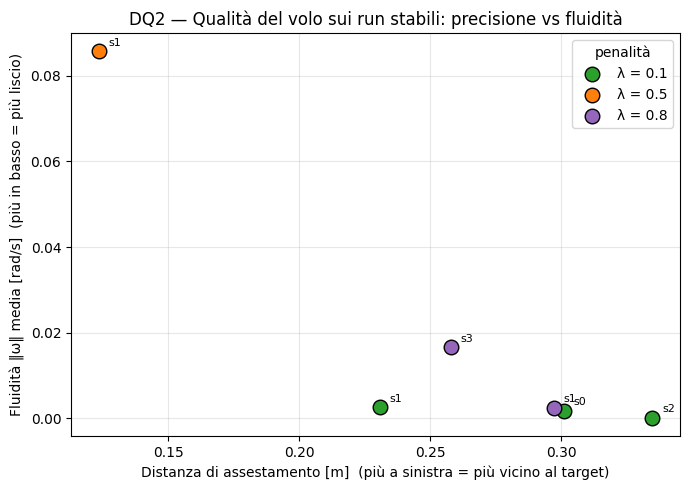

In [9]:
stable = df[df["behavior"] == "stable"].copy()
colL = {0.1: "tab:green", 0.5: "tab:orange", 0.8: "tab:purple"}

fig, ax = plt.subplots(figsize=(7, 5))
for lam in sorted(stable["lambda"].unique()):
    d = stable[stable["lambda"] == lam]
    ax.scatter(d["settle_dist_median_m"], d["fluidity_omega_mean"],
               s=110, color=colL[lam], label=f"λ = {lam}", edgecolor="black", zorder=3)
    for _, r in d.iterrows():
        ax.annotate(f"s{int(r['seed'])}", (r["settle_dist_median_m"], r["fluidity_omega_mean"]),
                    textcoords="offset points", xytext=(7, 4), fontsize=8)

ax.set_xlabel("Distanza di assestamento [m]  (più a sinistra = più vicino al target)")
ax.set_ylabel("Fluidità ‖ω‖ media [rad/s]  (più in basso = più liscio)")
ax.set_title("DQ2 — Qualità del volo sui run stabili: precisione vs fluidità")
ax.grid(True, alpha=0.3)
ax.legend(title="penalità")
fig.tight_layout()
out = FIG / "dq2_quality_stable.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Salvato:", out)
plt.show()

I run stabili presentano tutti una fluidità elevata (‖ω‖ dell'ordine di 10⁻³–10⁻² rad/s): quando il drone si stabilizza, il volo è effettivamente fermo e liscio. Si nota che il run stabile a λ=0.5 raggiunge la distanza di assestamento minore (si avvicina di più al target), pur con una ‖ω‖ leggermente superiore: in quel caso la penalità si traduce in un hover più preciso e attivo. La penalità non produce quindi un unico effetto, ma uno spettro di soluzioni qualitativamente diverse.


## 4. Sintesi quantitativa

La cella seguente esporta una tabella di sintesi in `results/tables/`, con il comportamento e, per i run stabili, le metriche di qualità del volo, per ogni combinazione λ–seme.


In [10]:
out_cols = ["lambda", "seed", "behavior", "stable_rate_pct", "spin_rate_pct",
            "crash_rate_pct", "settle_dist_median_m", "fluidity_omega_mean",
            "mech_dact_mean", "settle_time_median_s"]
tab = df[out_cols].copy()
tab.to_csv(TAB / "dq2_behavior_table.csv", index=False)
print("Salvata tabella in results/tables/dq2_behavior_table.csv")
tab

Salvata tabella in results/tables/dq2_behavior_table.csv


,lambda,seed,behavior,stable_rate_pct,spin_rate_pct,crash_rate_pct,settle_dist_median_m,fluidity_omega_mean,mech_dact_mean,settle_time_median_s
0,0.1,0,stable,100.0,0.0,0.0,0.3009,0.001785,0.000022,1.1333
1,0.1,1,stable,100.0,0.0,0.0,0.2306,0.002658,0.000156,0.0000
2,0.1,2,stable,100.0,0.0,0.0,0.3347,0.000131,0.000012,1.8667
3,0.5,1,stable,100.0,0.0,0.0,0.1234,0.085739,0.004858,0.3166
4,0.5,3,spin,0.0,98.0,2.0,NaN,NaN,NaN,NaN
5,0.5,4,spin,0.0,100.0,0.0,NaN,NaN,NaN,NaN
6,0.8,0,spin,0.0,100.0,0.0,NaN,NaN,NaN,NaN
7,0.8,1,stable,100.0,0.0,0.0,0.2970,0.002529,0.000319,1.1667
8,0.8,3,stable,100.0,0.0,0.0,0.2578,0.016628,0.000280,0.0000


## 5. Verdetto DQ2

**Domanda di ricerca:** la penalità quadratica sulle variazioni di comando ai motori produce un volo più fluido, e a quale costo sul tempo di raggiungimento del target?

**Risposta: l'effetto è più complesso di un semplice miglioramento monotòno della fluidità.**

- Senza penalità o con penalità lieve (λ ≤ 0.1) il drone converge in modo affidabile a un volo stabile e liscio.
- Con penalità media o forte la penalità apre soluzioni qualitativamente diverse — hover preciso e attivo, hover "pigro" a comandi quasi costanti, oppure avvitamento — e quale emerga dipende dal seme di addestramento. L'avvitamento è più frequente a penalità intermedia (λ=0.5).
- Quando il drone si stabilizza, il volo è sempre fluido; in particolare a λ=0.5, nei run stabili, l'hover è più preciso (distanza di assestamento minore).

**Interpretazione.** Mantenere l'hover richiede continue micro-correzioni della potenza dei motori. La penalità le rende costose: oltre una certa intensità, in alcuni addestramenti il drone trova un regime di rotazione che si auto-sostiene con comandi quasi costanti, evitando così le variazioni penalizzate. Questo regime di avvitamento è un minimo non desiderato della ricompensa modificata. Il fenomeno è analogo all'instabilità prodotta da un tasso di apprendimento troppo elevato: oltre una soglia, l'azione che dovrebbe stabilizzare introduce essa stessa instabilità.

### Limiti e precisazioni metodologiche
- Con tre semi per λ il comportamento bimodale e la sua dipendenza dal seme sono mostrati come fenomeno qualitativo; la frequenza esatta dell'avvitamento per ciascun λ non è stimabile con precisione statistica.
- La fluidità è misurata come velocità angolare del corpo, distinta dalla grandezza penalizzata (variazione del comando), per evitare circolarità nella misura.
- Il task non produce un hover di precisione assoluta sul target: la ricompensa nativa è piatta in prossimità del target. Le metriche di qualità sono quindi definite come grandezze continue di assestamento, non rispetto a una soglia di "arrivo".
